In [46]:
# ✅ Reload the datasets
import pandas as pd
import numpy as np

# Reload the datasets (replace the paths with actual ones if needed)
X_train = pd.read_csv('x_train.csv')
X_test = pd.read_csv('x_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

# Display dataset shapes
print("🔥 Dataset Shapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# ✅ Check Data Types
print("\n🔥 Data Types:")
print(f"X_train type: {type(X_train)}")
print(f"X_test type: {type(X_test)}")
print(f"y_train type: {type(y_train)}")
print(f"y_test type: {type(y_test)}")

# ✅ Check for Overlapping Samples
print("\n🔍 Checking for Overlapping Samples...")
train_set = set(map(tuple, X_train.values))
test_set = set(map(tuple, X_test.values))
overlapping_samples = train_set.intersection(test_set)

if overlapping_samples:
    print(f"❌ Overlapping Samples Found: {len(overlapping_samples)}")
else:
    print("✅ No overlapping samples detected.")

# ✅ Check for Target Leakage
print("\n🔍 Checking if target exists in X_train or X_test...")
target_in_train = 'Crime_Cluster' in X_train.columns
target_in_test = 'Crime_Cluster' in X_test.columns

if target_in_train or target_in_test:
    print("❌ Target label mistakenly included in the features!")
else:
    print("✅ No target leakage detected.")

# ✅ Check for Missing Values
print("\n🔍 Missing values in datasets:")
print("X_train missing values:")
print(X_train.isnull().sum().sum())
print("X_test missing values:")
print(X_test.isnull().sum().sum())
print(f"y_train missing values: {np.isnan(y_train).sum()}")
print(f"y_test missing values: {np.isnan(y_test).sum()}")

# ✅ Verify Consistent Target Labels
print("\n🔍 Unique values in y_train:", np.unique(y_train))
print("🔍 Unique values in y_test:", np.unique(y_test))


🔥 Dataset Shapes:
X_train shape: (217811, 31)
X_test shape: (54453, 31)
y_train shape: (217811, 1)
y_test shape: (54453, 1)

🔥 Data Types:
X_train type: <class 'pandas.core.frame.DataFrame'>
X_test type: <class 'pandas.core.frame.DataFrame'>
y_train type: <class 'pandas.core.frame.DataFrame'>
y_test type: <class 'pandas.core.frame.DataFrame'>

🔍 Checking for Overlapping Samples...
✅ No overlapping samples detected.

🔍 Checking if target exists in X_train or X_test...
✅ No target leakage detected.

🔍 Missing values in datasets:
X_train missing values:
0
X_test missing values:
0
y_train missing values: Crime_Cluster    0
dtype: int64
y_test missing values: Crime_Cluster    0
dtype: int64

🔍 Unique values in y_train: [0 1 2 3 4 5 6 7 8 9]
🔍 Unique values in y_test: [0 1 2 3 4 5 6 7 8 9]


In [47]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 🚀 XGBoost Model Configuration (Full Parameters)
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=10,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=500,                # 🔥 Number of boosting rounds
    learning_rate=0.05,               # 🔥 Step size shrinkage
    max_depth=8,                      # 🔥 Maximum depth of trees
    min_child_weight=3,               # 🔥 Minimum sum of instance weight needed in a child
    gamma=0.2,                        # 🔥 Minimum loss reduction
    subsample=0.8,                    # 🔥 Subsample ratio of the training instances
    colsample_bytree=0.8,             # 🔥 Subsample ratio of columns by tree
    reg_lambda=1,                      # 🔥 L2 regularization term
    reg_alpha=0.5,                     # 🔥 L1 regularization term
    use_label_encoder=False,           # ✅ Disable label encoder warning
    verbosity=1                        # 🔥 Verbosity level (1 for errors, 2 for warnings)
)


In [49]:
# ✅ Drop object columns
X_train = X_train.drop(['Date', 'Primary Type'], axis=1)
X_test = X_test.drop(['Date', 'Primary Type'], axis=1)

# 🚀 Verify the new shapes
print(f"🔥 X_train shape: {X_train.shape}")
print(f"🔥 X_test shape: {X_test.shape}")


🔥 X_train shape: (217811, 29)
🔥 X_test shape: (54453, 29)


In [50]:
# 🚀 Model Training
print("🚀 Training XGBoost Model...")
xgb_model.fit(X_train, y_train)


🚀 Training XGBoost Model...


c:\Users\atuly\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:34:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None, num_class=10, ...)

In [51]:
# 🔥 Predictions
y_pred = xgb_model.predict(X_test)


In [53]:
# 📊 Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🔥 Accuracy: {accuracy:.4f}\n")
print("📊 Classification Report:\n", classification_report(y_test, y_pred))


# 🛠️ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n🛠️ Confusion Matrix:\n", cm)




🔥 Accuracy: 0.9956

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4593
           1       1.00      0.99      1.00      8541
           2       1.00      0.99      1.00      2432
           3       1.00      1.00      1.00      4983
           4       1.00      1.00      1.00      5769
           5       1.00      1.00      1.00      7578
           6       1.00      1.00      1.00      4970
           7       1.00      1.00      1.00      4677
           8       0.99      1.00      1.00      5898
           9       0.99      0.99      0.99      5012

    accuracy                           1.00     54453
   macro avg       1.00      1.00      1.00     54453
weighted avg       1.00      1.00      1.00     54453


🛠️ Confusion Matrix:
 [[4556    0    0    0    0   15   10    0   12    0]
 [   0 8487    0    3   16    0    0    9   26    0]
 [   0    0 2418    0    0    0    0    0    0   14]
 [   0    0 

In [54]:
# ✅ Check columns in the final dataset
print("🔥 Final X_train Columns:")
print(X_train.columns)

print("\n🔥 Final X_test Columns:")
print(X_test.columns)


🔥 Final X_train Columns:
Index(['Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'District',
       'Community Area', 'Ward', 'Latitude', 'Longitude', 'Arrest', 'Domestic',
       'Weekday', 'WeekOfYear', 'Month_sin', 'Month_cos', 'Hour_sin',
       'Hour_cos', 'Crime_Count_7D', 'Crime_Count_30D', 'Crime_Count_90D',
       'Crime_MA_7D', 'Crime_MA_30D', 'Crime_Diff_7D_30D',
       'Crime_Diff_30D_90D', 'Season_Spring', 'Season_Summer', 'Season_Winter',
       'Primary_Type_Encoded'],
      dtype='object')

🔥 Final X_test Columns:
Index(['Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'District',
       'Community Area', 'Ward', 'Latitude', 'Longitude', 'Arrest', 'Domestic',
       'Weekday', 'WeekOfYear', 'Month_sin', 'Month_cos', 'Hour_sin',
       'Hour_cos', 'Crime_Count_7D', 'Crime_Count_30D', 'Crime_Count_90D',
       'Crime_MA_7D', 'Crime_MA_30D', 'Crime_Diff_7D_30D',
       'Crime_Diff_30D_90D', 'Season_Spring', 'Season_Summer', 'Season_Winter',
       'Primary_Type_Encoded'],
      dt

C:\Users\atuly\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


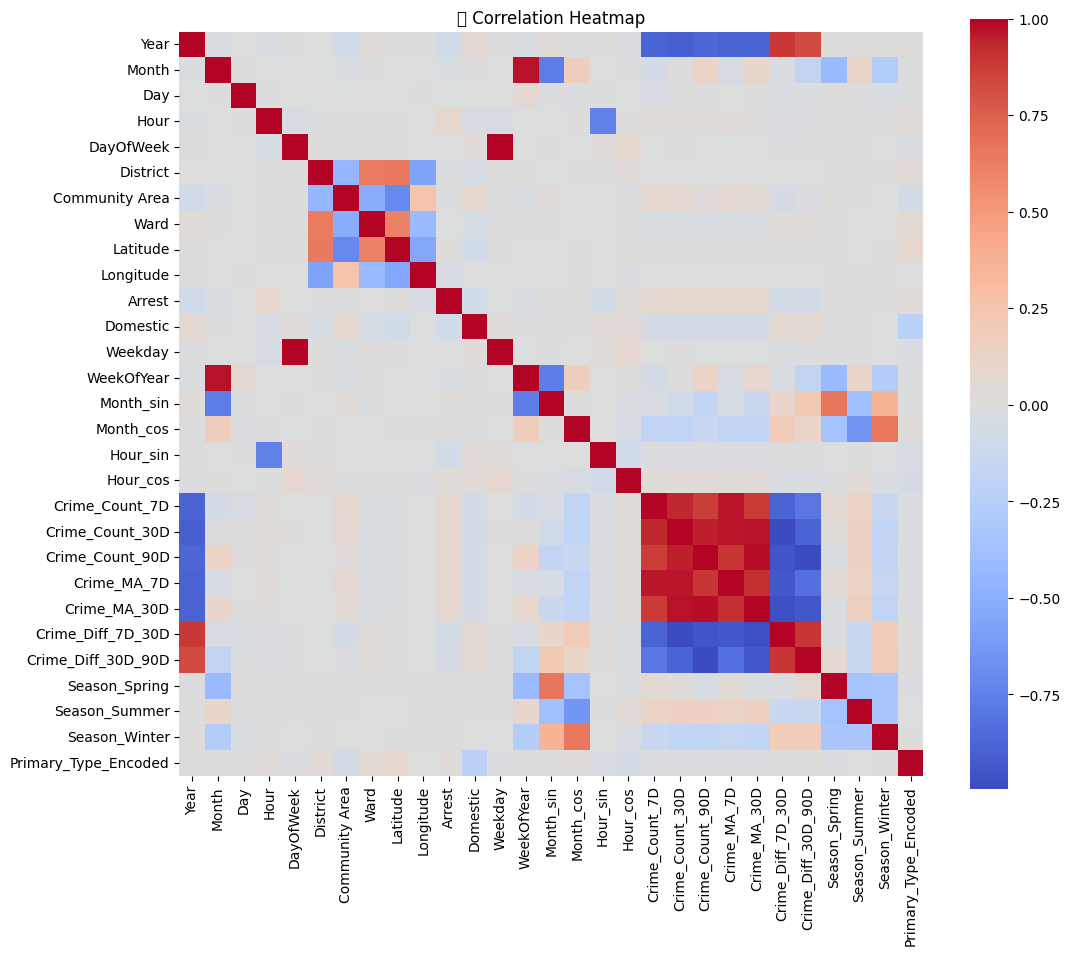


🔥 Highly Correlated Features:
 Crime_Count_30D     Crime_Diff_7D_30D     0.993856
Crime_Diff_7D_30D   Crime_Count_30D       0.993856
Crime_Diff_30D_90D  Crime_Count_90D       0.988260
Crime_Count_90D     Crime_Diff_30D_90D    0.988260
                    Crime_MA_30D          0.979236
Crime_MA_30D        Crime_Count_90D       0.979236
                    Crime_Diff_7D_30D     0.976579
Crime_Diff_7D_30D   Crime_MA_30D          0.976579
Crime_MA_30D        Crime_Count_30D       0.973766
Crime_Count_30D     Crime_MA_30D          0.973766
Month               WeekOfYear            0.969294
WeekOfYear          Month                 0.969294
Crime_MA_7D         Crime_Count_7D        0.965898
Crime_Count_7D      Crime_MA_7D           0.965898
Crime_MA_7D         Crime_Count_30D       0.961299
Crime_Count_30D     Crime_MA_7D           0.961299
                    Crime_Count_90D       0.948225
Crime_Count_90D     Crime_Count_30D       0.948225
                    Crime_Diff_7D_30D     0.947843

In [55]:
# ✅ Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = X_train.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title("🔥 Correlation Heatmap")
plt.show()

# Identify highly correlated pairs (threshold > 0.9)
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr >= 0.9][high_corr < 1.0]
print("\n🔥 Highly Correlated Features:\n", high_corr)


In [56]:
# ✅ Drop the highly correlated 'Crime_Count' features
X_train_refined = X_train.drop(['Crime_Count_7D', 'Crime_Count_30D', 'Crime_Count_90D'], axis=1)
X_test_refined = X_test.drop(['Crime_Count_7D', 'Crime_Count_30D', 'Crime_Count_90D'], axis=1)

# 🚀 Display the new shapes
print("🔥 Refined Dataset Shapes:")
print(f"X_train shape: {X_train_refined.shape}")
print(f"X_test shape: {X_test_refined.shape}")


🔥 Refined Dataset Shapes:
X_train shape: (217811, 26)
X_test shape: (54453, 26)


In [57]:
from sklearn.model_selection import cross_val_score

# 🚀 Initialize the XGBoost model with the same parameters
xgb_model_cv = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=9,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_lambda=1,
    reg_alpha=0,
    random_state=42,
    n_jobs=-1
)

# 🔥 Perform 5-Fold Cross-Validation
cv_scores = cross_val_score(xgb_model_cv, X_train_refined, y_train, cv=5, scoring='accuracy')

# 📊 Display Cross-Validation Results
print("\n🔥 Cross-Validation Results:")
print(f"CV Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")




🔥 Cross-Validation Results:
CV Scores: [0.99586805 0.99612047 0.99582205 0.99536293 0.99533998]
Mean Accuracy: 0.9957
Standard Deviation: 0.0003


🔥 Retraining XGBoost Model on Refined Dataset...
🔥 Final Accuracy: 0.9956

📊 Final Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4593
           1       1.00      0.99      1.00      8541
           2       1.00      0.99      1.00      2432
           3       1.00      1.00      1.00      4983
           4       1.00      1.00      1.00      5769
           5       1.00      1.00      1.00      7578
           6       1.00      1.00      1.00      4970
           7       1.00      1.00      1.00      4677
           8       0.99      1.00      1.00      5898
           9       0.99      0.99      0.99      5012

    accuracy                           1.00     54453
   macro avg       1.00      1.00      1.00     54453
weighted avg       1.00      1.00      1.00     54453



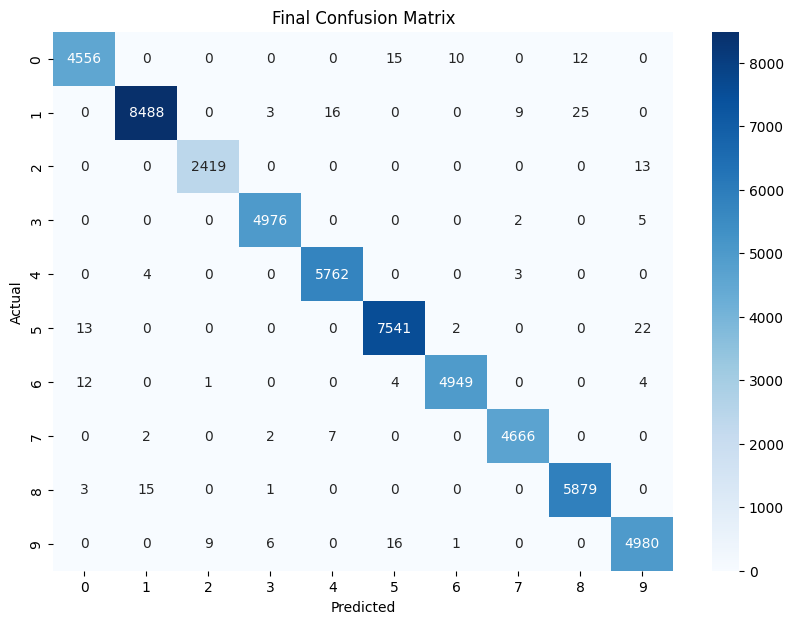

In [59]:
# 🚀 Import XGBoost
from xgboost import XGBClassifier

# 🚀 Retraining XGBoost on Refined Dataset
print("🔥 Retraining XGBoost Model on Refined Dataset...")

# Initialize XGBoost model with the final parameters
final_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softmax',
    num_class=10,
    random_state=42
)

# Fit the model on the full training set
final_model.fit(X_train, y_train)

# 🔥 Evaluate on the test set
y_pred_final = final_model.predict(X_test)

# ✅ Accuracy & Classification Report
accuracy_final = accuracy_score(y_test, y_pred_final)
print(f"🔥 Final Accuracy: {accuracy_final:.4f}")
print("\n📊 Final Classification Report:")
print(classification_report(y_test, y_pred_final))

# 🔥 Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=final_model.classes_, yticklabels=final_model.classes_)
plt.title("Final Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [60]:
# Calculate training accuracy
train_preds = final_model.predict(X_train)
train_acc = accuracy_score(y_train, train_preds)

# Calculate test accuracy
test_preds = final_model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)

print(f"🔥 Training Accuracy: {train_acc:.4f}")
print(f"🔥 Test Accuracy: {test_acc:.4f}")
print(f"🔍 Accuracy Difference: {abs(train_acc - test_acc):.4f}")


🔥 Training Accuracy: 0.9999
🔥 Test Accuracy: 0.9956
🔍 Accuracy Difference: 0.0043


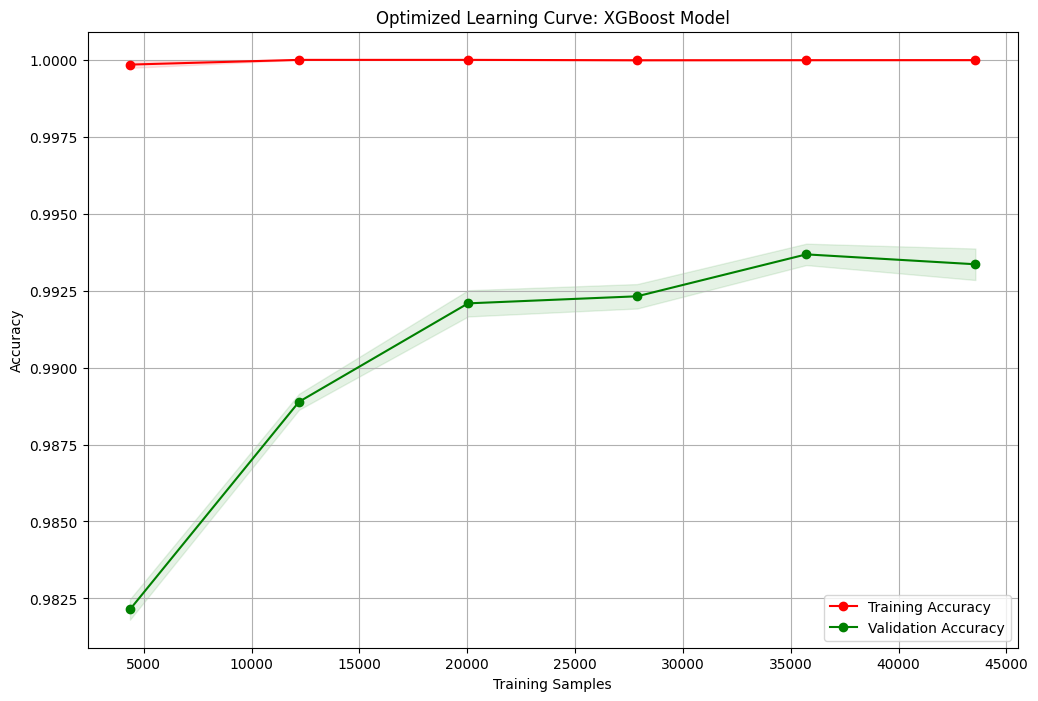

In [66]:
# ⚡ Use a smaller sample of the training data to speed up the process
X_sample = X_train_refined.sample(frac=0.3, random_state=42)

# ✅ Match the corresponding labels using iloc
y_sample = y_train.iloc[X_sample.index]

# 🚀 Faster Learning Curve Function
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve_fast(estimator, X, y, cv=3, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 6)):
    plt.figure(figsize=(12, 8))

    # Generate learning curve
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='accuracy'
    )

    # Mean and standard deviation
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plotting
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Accuracy")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Validation Accuracy")

    plt.title("Optimized Learning Curve: XGBoost Model")
    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# 🛠️ Call the function with the sampled data
plot_learning_curve_fast(final_model, X_sample, y_sample)


In [70]:
# 🔥 Retrain the XGBoost model with the refined dataset (26 features)
final_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=10,
    eval_metric='mlogloss',
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    min_child_weight=3,
    gamma=0.2,
    colsample_bytree=0.8
)

# ⚙️ Fit the model
final_model.fit(X_train_refined, y_train)

# ✅ Save the final model with the correct features
joblib.dump(final_model, "xgboost_final_model_refined.pkl")
print("✅ Model saved as 'xgboost_final_model_refined.pkl'")


✅ Model saved as 'xgboost_final_model_refined.pkl'


In [71]:
# 🔥 Load the refined model
loaded_model = joblib.load("xgboost_final_model_refined.pkl")

# 🔍 Test prediction on refined dataset
sample_prediction = loaded_model.predict(X_test_refined[:5])
print("📊 Sample Prediction:", sample_prediction)


📊 Sample Prediction: [6 9 0 4 1]


🔥 Accuracy: 0.9957578094870806

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4593
           1       1.00      0.99      1.00      8541
           2       1.00      0.99      0.99      2432
           3       1.00      1.00      1.00      4983
           4       1.00      1.00      1.00      5769
           5       1.00      1.00      1.00      7578
           6       1.00      1.00      1.00      4970
           7       1.00      1.00      1.00      4677
           8       0.99      1.00      1.00      5898
           9       0.99      0.99      0.99      5012

    accuracy                           1.00     54453
   macro avg       1.00      1.00      1.00     54453
weighted avg       1.00      1.00      1.00     54453



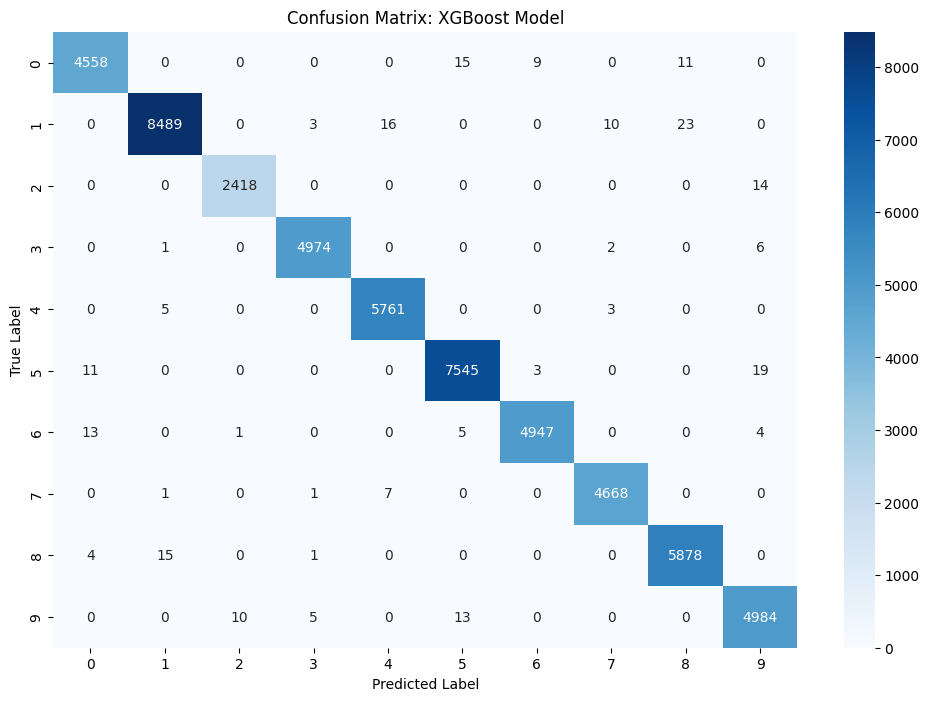

In [72]:
# 🔥 Make predictions on the entire test set
y_pred = loaded_model.predict(X_test_refined)

# 📊 Classification report
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("🔥 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

# 🔍 Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: XGBoost Model")
plt.show()
